# Humpback Whale Identification — ArcFace Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## ArcFace Training

**ArcFace** (Deng et al., CVPR 2019 — course slides 31–33) modifies the classification
head to enforce angular margin between classes on a hypersphere.

Instead of computing logits as `W · f(x)`, ArcFace:
1. L2-normalizes both weight vectors and embeddings
2. Computes cosine similarity (= angular distance on the hypersphere)
3. Adds an angular penalty `m` to the correct class's angle
4. Scales by factor `s` before softmax

This forces the model to cluster same-class embeddings tightly and push different
classes apart by at least `m` radians. The key advantage over triplet loss:
**no pair/triplet mining is needed** — ArcFace works with standard batching (slide 31).

We initialize from the baseline's backbone + embedding weights, replacing only
the classifier head with the ArcFace head.


## Setup & Imports

In [1]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_dataloaders,
 )
from models import build_model
from training import train
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


## Experiment Configuration

In [ ]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="arcface_effnetb5",
    description="ArcFace angular margin loss, initialized from baseline",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="arcface",       # ← ArcFace head instead of linear
    arcface_scale=30.0,        # Logit scale factor
    arcface_margin=0.5,        # Angular margin (radians)

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=2,  # Shorter freeze: backbone is already good from baseline
    freeze_bn=True,
    epochs=35,
    batch_size=16,
    accumulation_steps=2,
    use_amp=False,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,              # Slightly lower than baseline (fine-tuning, not fresh)
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="arcface_ce",    # Standard CE on the ArcFace-modified logits
    label_smoothing=0.0,       # No label smoothing with ArcFace (margin handles it)
    use_class_weights=False,   # ArcFace margin handles class separation

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    # UPDATE THIS PATH to your best baseline checkpoint:
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("ArcFace config:")
print(config.summary())


ArcFace config:
efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=24×2 | head=arcface(s=30.0,m=0.5)


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [4]:
TRAINING_ENABLED = True
EXPERIMENT_ID = "unknown"

if TRAINING_ENABLED:
    #manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

[16:05:04] New experiment: 20260527_160504_arcface_effnetb5_dbfd5eb7
[16:05:04] Config: efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=24×2 | head=arcface(s=30.0,m=0.5)
[16:05:04] No matching resume target found. Starting new experiment.


[16:05:06] Backbone FROZEN for first 2 epochs

Model: efficientnet_b5 (head=arcface)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,566,896
  Backbone:         28,340,784
  Head:              3,226,112
  Trainable:         3,226,112 (10.2%)
  Frozen:           28,340,784 (89.8%)

[16:05:06] Loss: arcface_ce | Head: arcface
[16:05:06] 
Starting training: 35 epochs, effective batch size = 48


  Train Ep 0:   0%|          | 0/310 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/156 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x776da5c2a8e0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x776da5c2a8e0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

...

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

[16:10:27] Epoch   1/35 [FROZEN] | Train Loss: 17.8075  Acc: 29.3% | Val known_recall@1: 35.7%  LR: 4.99e-04 | Time: 2.4m
[16:10:27]   ✓ New best model saved (epoch 1, known_recall@1=0.3571)
[16:10:27] 
[16:10:27] BACKBONE UNFROZEN at epoch 2
[16:10:27] ============================================================


Model: efficientnet_b5 (head=arcface)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,566,896
  Backbone:         28,340,784
  Head:              3,226,112
  Trainable:        31,566,896 (100.0%)
  Frozen:                    0 (0.0%)



  Train Ep 2:   0%|          | 0/310 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x776da5c2a8e0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:   File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x776da5c2a8e0>: 
can only test a child process
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x776da5c2a8e0>self._shutdown_workers()

Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/venv/main/lib/python3.12

OutOfMemoryError: CUDA out of memory. Tried to allocate 82.00 MiB. GPU 0 has a total capacity of 23.43 GiB of which 70.19 MiB is free. Including non-PyTorch memory, this process has 23.35 GiB memory in use. Of the allocated memory 22.95 GiB is allocated by PyTorch, and 109.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


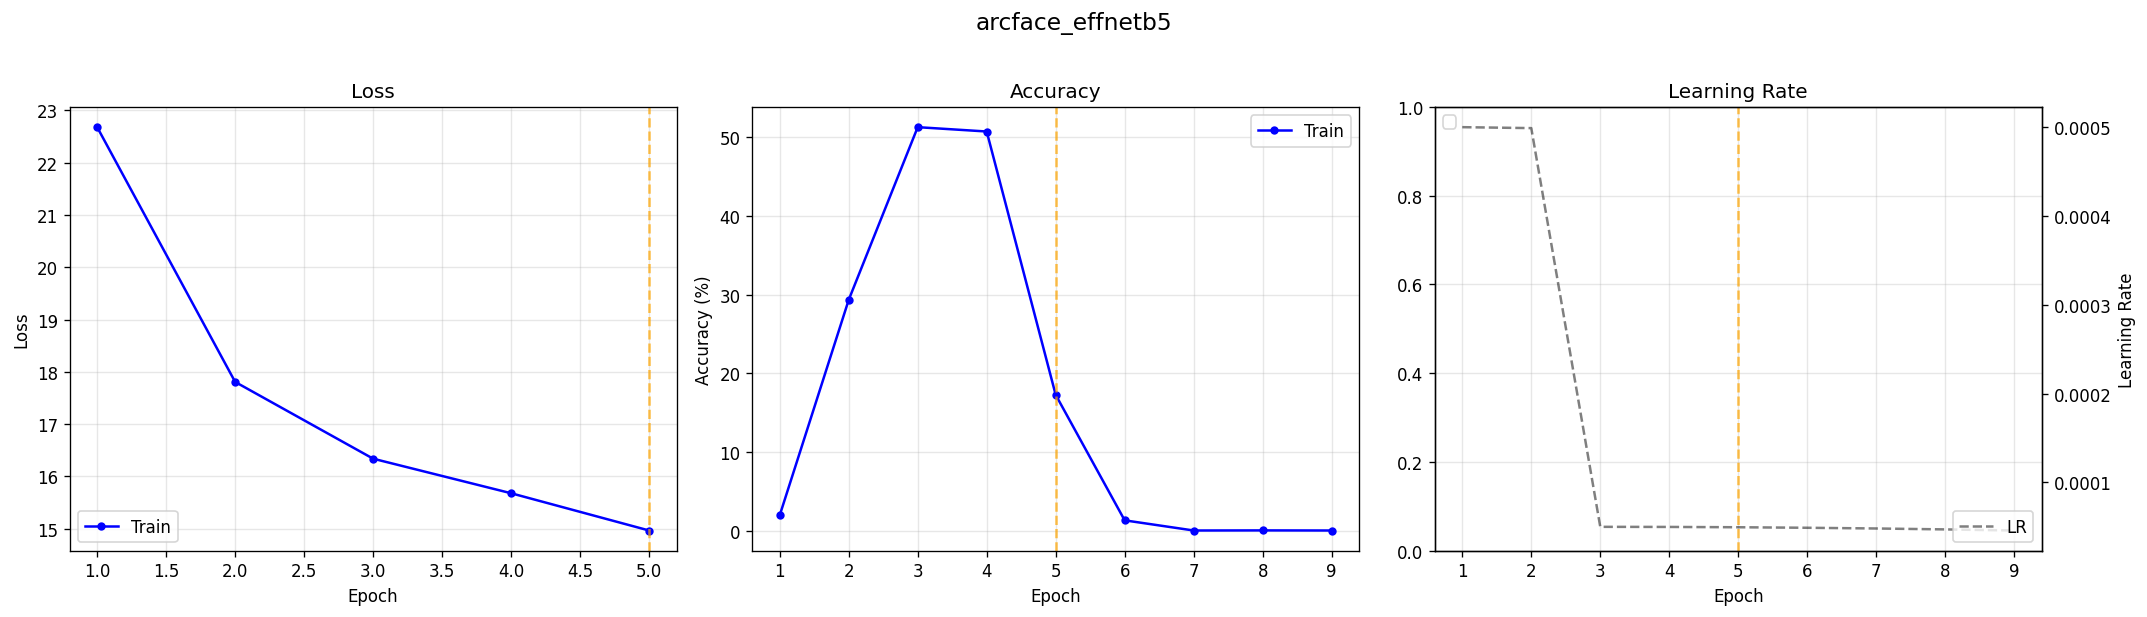

In [ ]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [ ]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "val_loss", "val_known_acc",
            "val_mean_known_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : nan


## Embedding Quality


In [ ]:
eval_config, data = get_eval_config_and_data()

arcface_model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(arcface_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("ArcFace retrieval performance:")
arcface_retrieval = evaluate_retrieval(
    arcface_model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(arcface_model, val_loader, data, device,
                    title="ArcFace Embedding — t-SNE", combine_loaders=[train_loader])

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)
[15:07:46] Loading checkpoint: experiments/20260527_144112_arcface_effnetb5_208d7e63/checkpoints/best.pth
[15:07:46] Resuming from epoch 3
ArcFace retrieval performance:


NameError: name 'evaluate_retrieval' is not defined